# Exoplanet Transit Light Curve
### ADAPT Workshop — Day 3
**Philippine Space Agency × CVIF-RCTP**

---

This notebook processes the photometry CSV file from Afterglow and produces a differential light curve showing an exoplanet transit dip.

**Instructions:** Run each cell in order by pressing `Shift + Enter`. Do not skip any cell.

## Step 1: Import Libraries
These are the tools we need for reading, processing, and plotting the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2: Load the CSV File
We'll use the `wasp 18 b.csv` file included in this folder.

In [32]:
filename = 'new1.csv'
print('Using file:', filename)

Using file: new1.csv


## Step 3: Load and Preview the Data
This reads your CSV and shows you the first few rows so you can confirm it loaded correctly.

In [33]:
df = pd.read_csv(filename)

print('Total rows:', len(df))
print('Sources found:', df['id'].unique())
print()
df[['id', 'jd', 'flux', 'flux_error', 'mag']].head(10)

Total rows: 144
Sources found: ['SRC8' 'SRC9']



,id,jd,flux,flux_error,mag
0,SRC8,2.460965e+06,927757.529988,966.258641,6.274217
1,SRC9,2.460965e+06,14372.001560,124.192861,10.799010
2,SRC8,2.460965e+06,941291.523778,973.143984,6.258493
3,SRC9,2.460965e+06,14737.466331,126.083240,10.771746
4,SRC8,2.460965e+06,887009.530688,945.538574,6.322982
5,SRC9,2.460965e+06,13979.140166,122.486133,10.829102
6,SRC8,2.460965e+06,888250.108788,945.062033,6.321465
7,SRC9,2.460965e+06,14140.694320,123.435874,10.816626
8,SRC8,2.460965e+06,820064.100849,908.352082,6.408184
9,SRC9,2.460965e+06,12918.961156,119.455525,10.914734


## Step 4: Separate the Host Star and Reference Star

- **SRC2** = Host star (the star with the transiting exoplanet)
- **SRC3** = Reference star (a nearby stable star used for comparison)

> **Note:** If your source IDs are different (e.g. SRC1, SRC4), change the values below to match.

In [34]:
# Change these if your source IDs are different
HOST_STAR_ID = 'SRC8'
REFERENCE_STAR_ID = 'SRC9'

host = df[df['id'] == HOST_STAR_ID].copy().reset_index(drop=True)
ref  = df[df['id'] == REFERENCE_STAR_ID].copy().reset_index(drop=True)

print(f'Host star frames:      {len(host)}')
print(f'Reference star frames: {len(ref)}')

time_span_hours = (host['jd'].max() - host['jd'].min()) * 24
print(f'Observation span:      {time_span_hours:.2f} hours')

Host star frames:      72
Reference star frames: 72
Observation span:      7.77 hours


## Step 5: Check the Reference Star

Before using the reference star to calibrate our host star, we need to verify it is stable — its brightness should stay roughly constant throughout the observation.

A flat line means it is a good reference. A trending or variable line means you should pick a different reference star.

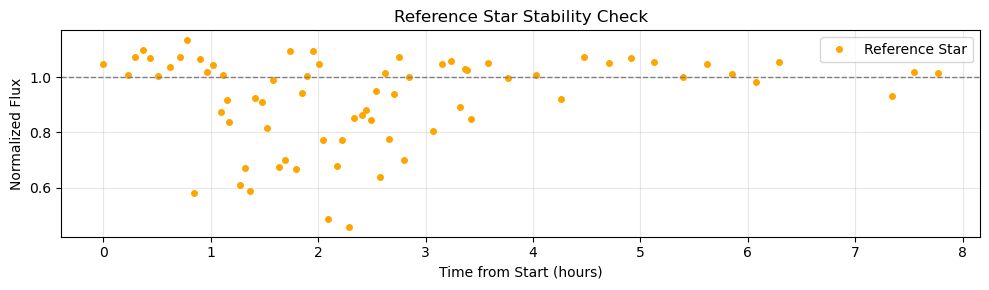

Reference star flux variation (std/mean): 17.73%
A value below 5% indicates a stable reference star.


In [35]:
# Convert JD to hours from start for easier reading
t0= host['jd'].min()
host['time_hrs'] = (host['jd'] - t0) * 24
ref['time_hrs']  = (ref['jd']  - t0) * 24

# Normalize reference flux to its median for easier visual check
ref_median = ref['flux'].median()
ref['flux_norm'] = ref['flux'] / ref_median

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ref['time_hrs'], ref['flux_norm'],
        'o', color='orange', markersize=4, label='Reference Star')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Time from Start (hours)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Reference Star Stability Check')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Reference star flux variation (std/mean): {ref["flux"].std()/ref["flux"].mean()*100:.2f}%')
print('A value below 5% indicates a stable reference star.')

## Step 6: Compute the Differential Light Curve

We divide the host star flux by the reference star flux for each frame. This cancels out atmospheric effects that affect both stars equally — what remains is the true brightness variation of the host star.

A **dip** in this ratio is the exoplanet blocking part of the host star's light.

In [29]:
# Merge host and reference on time
merged = pd.merge(
    host[['jd', 'time_hrs', 'flux', 'flux_error']],
    ref[['jd', 'flux', 'flux_error']],
    on='jd',
    suffixes=('_host', '_ref')
)

# Compute flux ratio
merged['flux_ratio'] = merged['flux_host'] / merged['flux_ref']

# Propagate uncertainty
merged['flux_ratio_err'] = merged['flux_ratio'] * np.sqrt(
    (merged['flux_error_host'] / merged['flux_host'])**2 +
    (merged['flux_error_ref']  / merged['flux_ref'])**2
)

print(f'Frames in light curve: {len(merged)}')
print(f'Flux ratio range: {merged["flux_ratio"].min():.4f} to {merged["flux_ratio"].max():.4f}')

Frames in light curve: 72
Flux ratio range: 37.9160 to 40.7477


## Step 7: Remove Outliers
Some frames may have bad data due to clouds or tracking errors. We remove points more than 3 standard deviations from the median.

In [36]:
median = merged['flux_ratio'].median()
std    = merged['flux_ratio'].std()

clean = merged[
    (merged['flux_ratio'] >= median - 3 * std) &
    (merged['flux_ratio'] <= median + 3 * std)
].copy()

removed = len(merged) - len(clean)
print(f'Frames removed as outliers: {removed}')
print(f'Frames remaining:           {len(clean)}')

Frames removed as outliers: 0
Frames remaining:           72


## Step 8: Plot the Transit Light Curve

This is the main result. Look for a **dip** — a temporary drop in the flux ratio — which is the exoplanet passing in front of its host star.

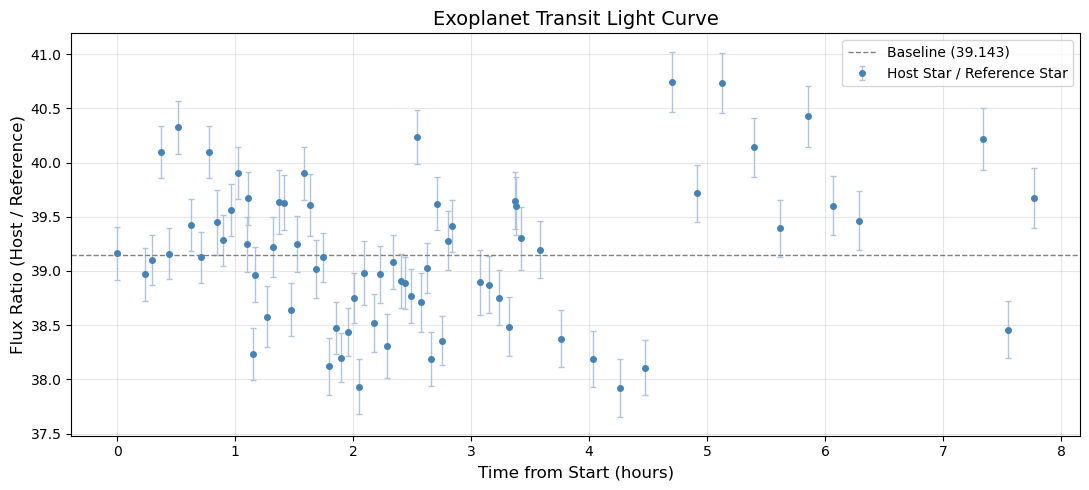

Baseline flux ratio:  39.1434
Minimum flux ratio:   37.9160
Estimated dip depth:  3.14%


In [37]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.errorbar(
    clean['time_hrs'],
    clean['flux_ratio'],
    yerr=clean['flux_ratio_err'],
    fmt='o',
    color='steelblue',
    markersize=4,
    ecolor='lightsteelblue',
    elinewidth=1,
    capsize=2,
    label='Host Star / Reference Star'
)

# Baseline reference line
baseline = np.median(clean['flux_ratio'])
ax.axhline(baseline, color='gray', linestyle='--',
           linewidth=1, label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Time from Start (hours)', fontsize=12)
ax.set_ylabel('Flux Ratio (Host / Reference)', fontsize=12)
ax.set_title('Exoplanet Transit Light Curve', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estimate transit depth
min_ratio = clean['flux_ratio'].min()
depth_pct = (baseline - min_ratio) / baseline * 100
print(f'Baseline flux ratio:  {baseline:.4f}')
print(f'Minimum flux ratio:   {min_ratio:.4f}')
print(f'Estimated dip depth:  {depth_pct:.2f}%')

## Step 9: Save the Plot
Downloads the light curve as an image file you can include in your group presentation.

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.errorbar(
    clean['time_hrs'],
    clean['flux_ratio'],
    yerr=clean['flux_ratio_err'],
    fmt='o',
    color='steelblue',
    markersize=4,
    ecolor='lightsteelblue',
    elinewidth=1,
    capsize=2,
    label='Host Star / Reference Star'
)

baseline = np.median(clean['flux_ratio'])
ax.axhline(baseline, color='gray', linestyle='--',
           linewidth=1, label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Time from Start (hours)', fontsize=12)
ax.set_ylabel('Flux Ratio (Host / Reference)', fontsize=12)
ax.set_title('Exoplanet Transit Light Curve', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('transit_lightcurve.png', dpi=150)
plt.show()

files.download('transit_lightcurve.png')
print('Plot saved and downloaded as transit_lightcurve.png')